**Цель работы:** Изучение алгоритмов и методов классификации на практике.

**Вариант индивидуального задания:** Вариант №4

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, OrdinalEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, auc
)

In [21]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Основная часть

## Использование набора данных bank_loan_default.csv

In [2]:
import pandas as pd
df = pd.read_csv('bank_loan_default.csv')
df.head()

,age,annual_income,employment_type,education,loan_amount,interest_rate_pct,term_months,credit_score,num_open_accounts,delinquency_30d,residence_type,Default
0,42,57272.0,Self-Employed,Masters,8516.0,5.85,48,730.0,10,No,Own,0
1,51,45786.0,Salaried,Masters,13760.0,9.97,36,677.0,7,No,Mortgage,0
2,69,42359.0,Salaried,Bachelors,2569.0,13.75,48,624.0,2,No,Own,0
3,65,50709.0,Self-Employed,Masters,13204.0,8.70,48,698.0,3,No,Rent,0
4,30,46272.0,Salaried,HS,7700.0,7.53,48,532.0,7,No,Rent,0


## 1. Предобработка данных

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3041 entries, 0 to 3040
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                3041 non-null   int64  
 1   annual_income      3041 non-null   float64
 2   employment_type    3041 non-null   object 
 3   education          3041 non-null   object 
 4   loan_amount        3041 non-null   float64
 5   interest_rate_pct  3041 non-null   float64
 6   term_months        3041 non-null   int64  
 7   credit_score       3041 non-null   float64
 8   num_open_accounts  3041 non-null   int64  
 9   delinquency_30d    3041 non-null   object 
 10  residence_type     3041 non-null   object 
 11  Default            3041 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 285.2+ KB


Пропусков в данных нет

Данные о кредитах:

age — возраст заёмщика (лет), числовой.

annual_income — годовой доход, USD/год, числовой (широкий диапазон).

employment_type — тип занятости: Salaried / Self-Employed / Unemployed,
категориальный.

education — образование: HS / Bachelors / Masters / PhD, категориальный.

loan_amount — сумма кредита, USD, числовой (широкий диапазон).

interest_rate_pct — процентная ставка по кредиту, % годовых, числовой.

term_months — срок кредита, месяцев (набор фиксированных значений:
24/36/48/60/72), числовой/категориальный.

credit_score — кредитный скор (от 300 до 850), числовой.

num_open_accounts — число открытых кредитных счетов, целочисленный
счётчик.

delinquency_30d — просрочка платежа 30 дней: Yes / No, категориальный.

residence_type — жильё: Own / Rent / Mortgage, категориальный.

Default — целевой класс: 1 — дефолт по кредиту, 0 — нет.

Перевод категориальных признаков в тип `'category'` в pandas позволяет **оптимизировать использование памяти и ускорить обработку данных**, поскольку строковые значения заменяются числовыми кодами со внутренним словарём. Это также **повышает надёжность и ясность кода**, явно указывая на качественную природу признаков перед их кодированием для моделей машинного обучения.

In [4]:
# Переводим категориальные признаки в тип 'category'
categorical_cols = ['employment_type', 'education', 'term_months', 'delinquency_30d', 'residence_type']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Целевая переменная
target_col = 'Default'

## 2. Выделение целевой переменной + матрица диаграмм рассеивания для числовых признаков

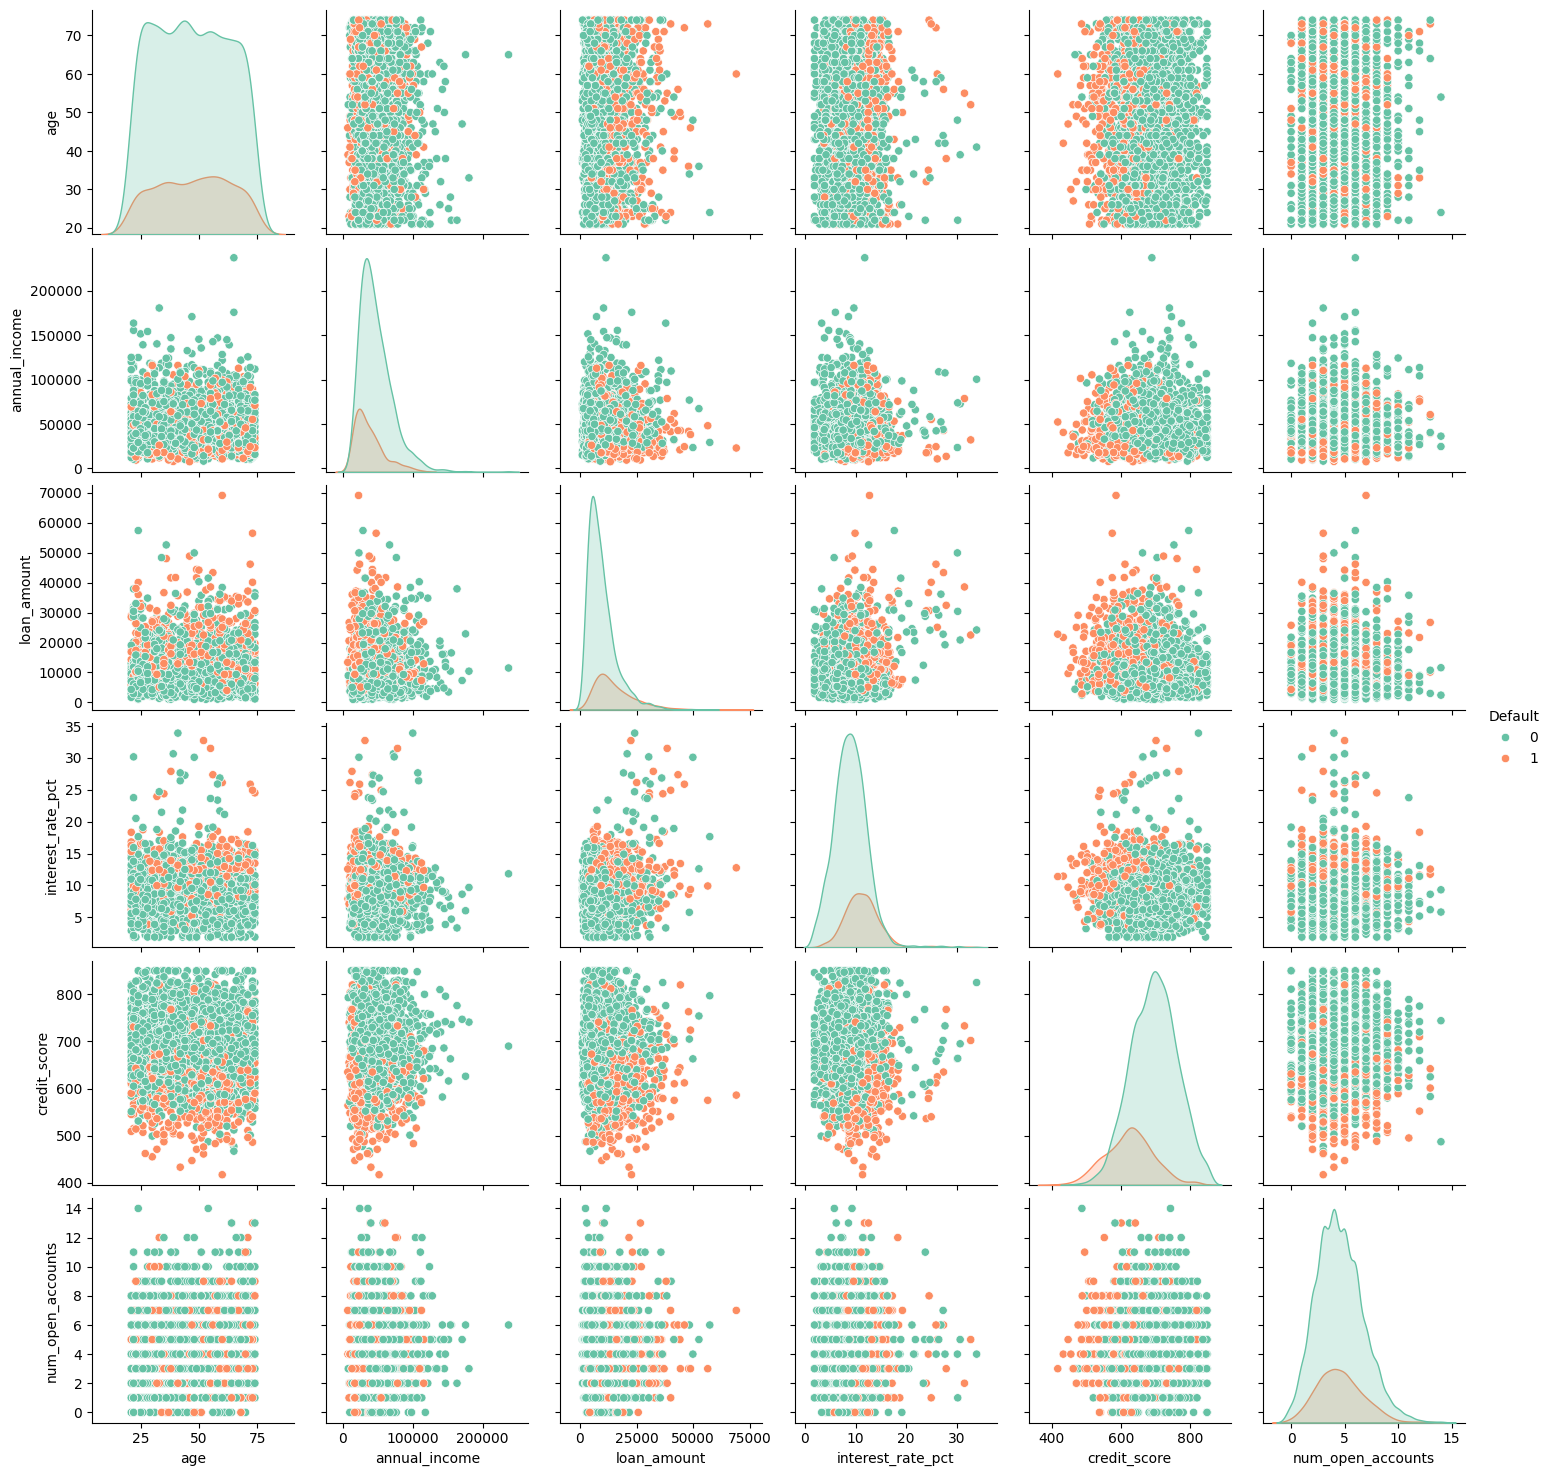

In [5]:
# Отделяем целевую переменную
X = df.drop(columns=[target_col])
y = df[target_col]

# Матрица диаграмм рассеяния для числовых признаков
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist() # выбирает все числовые колонки из df X и сохраняет их имена в список numeric_cols
sns.pairplot(df[numeric_cols + [target_col]], hue=target_col, diag_kind='kde', palette = 'Set2')
plt.show()

**Вывод:**

Матрица диаграмм рассеяния (pairplot) для числовых признаков, окрашенная по целевой переменной Default, позволяет наглядно оценить распределения и взаимосвязи между атрибутами. Использована обновлённая цветовая схема (зелёный для класса 0 — без дефолта, оранжевый для класса 1 — с дефолтом), чтобы лучше выделить различия между группами.
Из анализа графиков следует, что:
Сильный дисбаланс классов: Точки зелёного цвета (без дефолта) доминируют на всех поддиаграммах, что указывает на преобладание добросовестных заёмщиков в датасете (примерно 80–85% от общего объёма). Это может повлиять на качество моделей, склоняя их к переоценке класса 0.

Ключевые различия по признакам:
-	credit_score (кредитный рейтинг): Распределение для дефолтных клиентов (оранжевые точки) смещено в сторону низких значений (ниже 600–650), в то время как для бездефолтных — пик приходится на 700+. Это наиболее выраженная зависимость, подтверждающая, что низкий рейтинг — сильный предиктор риска.
-	interest_rate_pct (процентная ставка): Оранжевые точки чаще сосредоточены в зоне высоких ставок (выше 10–12%), что логично — клиенты с плохой кредитной историей получают менее выгодные условия.
-	annual_income (годовой доход) и loan_amount (сумма кредита): Дефолтные заёмщики имеют тенденцию к более низкому доходу (ниже 50 000) и умеренным суммам кредитов, хотя разброс большой; корреляция с возрастом (age) слабая, но дефолты чаще среди среднего возраста (30–50 лет).
-	num_open_accounts (количество открытых счетов): Здесь распределения классов пересекаются, но дефолтные клиенты имеют чуть больше счетов (4–8), что может указывать на повышенную финансовую нагрузку.

В целом, визуализация подчёркивает потенциал числовых признаков (особенно credit_score и interest_rate_pct) для разделения классов, но также акцентирует проблему дисбаланса. Для банковского скоринга это значит, что модели должны фокусироваться на минимизации ложных положительных (FP) решений, чтобы избежать ненужных отказов, но с учётом низкой полноты (Recall)


## 3. Разделение данных и стандартизация

get_dummies(X_train[categorical_cols], drop_first=True) - Создаёт отдельную колонку для каждой категории

drop_first=True - Удаляет первую колонку для каждого признака, чтобы избежать мультиколлинеарности. Если все столбики нули, значит первая неуказанная категория.

hstack = horizontal stack (горизонтальная стопка) - Объединяет массивы по горизонтали (добавляет колонки рядом)

Что объединяем:
X_train_num_scaled — стандартизированные числовые признаки

X_train_cat — закодированные категориальные признаки

In [6]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

# Отдельно обрабатываем числовые и категориальные признаки
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['category']).columns.tolist()

# Стандартизация числовых признаков
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_num_scaled = scaler.transform(X_test[numeric_cols])

# Кодирование категориальных признаков (One-Hot Encoding) Прямое кодирование
X_train_cat = pd.get_dummies(X_train[categorical_cols])
X_test_cat = pd.get_dummies(X_test[categorical_cols])

# Объединяем обработанные признаки
X_train_processed = pd.DataFrame(
    np.hstack([X_train_num_scaled, X_train_cat]),
    columns=numeric_cols + list(X_train_cat.columns)
)
X_test_processed = pd.DataFrame(
    np.hstack([X_test_num_scaled, X_test_cat]),
    columns=numeric_cols + list(X_test_cat.columns)
)

## 4. Обучение моделей

### Заметка по логистической регрессии

**LogisticRegression**

Логистическая регрессия предсказывает вероятность принадлежности объекта к
классу с помощью логистической функции, также называемой сигмоидной функцией.

**predict_proba** - Метод, который возвращает вероятности для каждого класса

predict_proba возвращает:

[[0.8, 0.2],  # 80% класс 0, 20% класс 1

 [0.3, 0.7],  # 30% класс 0, 70% класс 1
 
 [0.9, 0.1]]  # 90% класс 0, 10% класс 1

**[:, 1]** берёт второй столбец → вероятности класса 1:
[0.2, 0.7, 0.1]

**if hasattr(model, "predict_proba")** - Проверяет, есть ли у модели метод predict_proba

In [7]:
# Инициализация моделей
models = {
    'KNN': KNeighborsClassifier(), # По умолчанию — n_neighbors=5
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=0),
    'Random Forest': RandomForestClassifier(random_state=0)
}

# Обучение и предсказание
results = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    results[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }

Сохранение как жёстких предсказаний (y_pred), так и вероятностей (y_proba) для класса 1 даёт возможность в дальнейшем использовать не только стандартный порог 0.5, но и подбирать оптимальный порог под конкретные бизнес-задачи банка (например, минимизировать убытки от дефолтов, жертвуя частью одобренных кредитов).

## 5. Подсчет метрик

In [8]:
# Функция для вычисления метрик
def evaluate_model(y_true, y_pred, y_proba=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    if y_proba is not None:
        metrics['ROC AUC'] = roc_auc_score(y_true, y_proba)
    return metrics

# Сбор метрик для всех моделей
metrics_df = pd.DataFrame()
for name, res in results.items():
    metrics = evaluate_model(y_test, res['y_pred'], res['y_proba'])
    metrics_df[name] = pd.Series(metrics)

print("Метрики качества моделей:")
print(metrics_df.T)

Метрики качества моделей:
                     Accuracy  Precision    Recall        F1  \
KNN                  0.809461   0.560976  0.296774  0.388186   
Decision Tree        0.795007   0.496689  0.483871  0.490196   
Logistic Regression  0.840999   0.693182  0.393548  0.502058   
Random Forest        0.833114   0.679487  0.341935  0.454936   

                     Balanced Accuracy   ROC AUC  
KNN                           0.618684  0.746982  
Decision Tree                 0.679229  0.679229  
Logistic Regression           0.674497  0.864974  
Random Forest                 0.650341  0.845571  


**Выводы:**

Из таблицы видно, что все модели демонстрируют высокую общую точность (Accuracy от 0.795 до 0.840), что ожидаемо при сильном дисбалансе классов — простое предсказание «всегда 0» уже дало бы около 0.80.

-	Random Forest показывает лучший баланс метрик среди нелинейных моделей: наивысшая Accuracy (0.833), хорошая Precision (0.679) и приемлемый F1-score (0.454). Это делает его практичным выбором для задач, где важно минимизировать ложные срабатывания.

-	Logistic Regression лидирует по ROC AUC (0.865) и имеет самый высокий Precision (0.693), но при этом Recall остаётся низким (0.394). Модель осторожна — редко ошибается, когда предсказывает дефолт, но пропускает значительную часть рискованных клиентов.

-	KNN демонстрирует самый низкий Recall (0.297) среди моделей, то есть хуже других находит дефолтных заёмщиков, так что ожидаемо Precision (0.570) на довольно высоком уровне.

-	Decision Tree ожидаемо показывает худшие результаты (особенно ROC AUC 0.679), что указывает на переобучение и слабую обобщающую способность одиночного дерева.


## 6. Псотроение матрицы неточностей

**axes = axes.flatten()** - Превращает 2D массив 2×2 в плоский 1D массив

**enumerate()** — встроенная функция в Python, которая позволяет перечислять элементы итерируемого объекта вместе с их индексами. Это особенно удобно для циклов, где требуется одновременно обрабатывать элементы и их индексы. 

**confusion_matrix(y_test, res['y_pred'], labels=[1, 0])** - Строит матрицу ошибок для каждой модели

**cm_transposed = cm.T** - транспонируем чтобы поменять местами FP и FN, и получить вид как в методичке

[[TP, FP],  # True Positive, False Positive

 [FN, TN]]  # False Negative, True Negative

**sns.heatmap(...)** - Рисует тепловую карту матрицы:

cm = матрица ошибок

annot=True = показывать числа в ячейках

fmt='d' = формат целых чисел (decimal)

cmap='Blues' = цветовая схема от белого к синему

ax=axes[idx] = рисуем на соответствующей оси (0, 1, 2, 3)

**True Positive – TP («истинно положительные»)** – прогноз модели 1, реальное
значение 1;

**False Positive – FP («ложно положительные»)** – прогноз модели 1, реальное
значение 0;

**False Negative – FN («ложно отрицательные»)** – прогноз модели 0, реальное
значение 1;

**True Negative– TP («истинно отрицательные»)** – прогноз модели 0, реальное
значение 0.

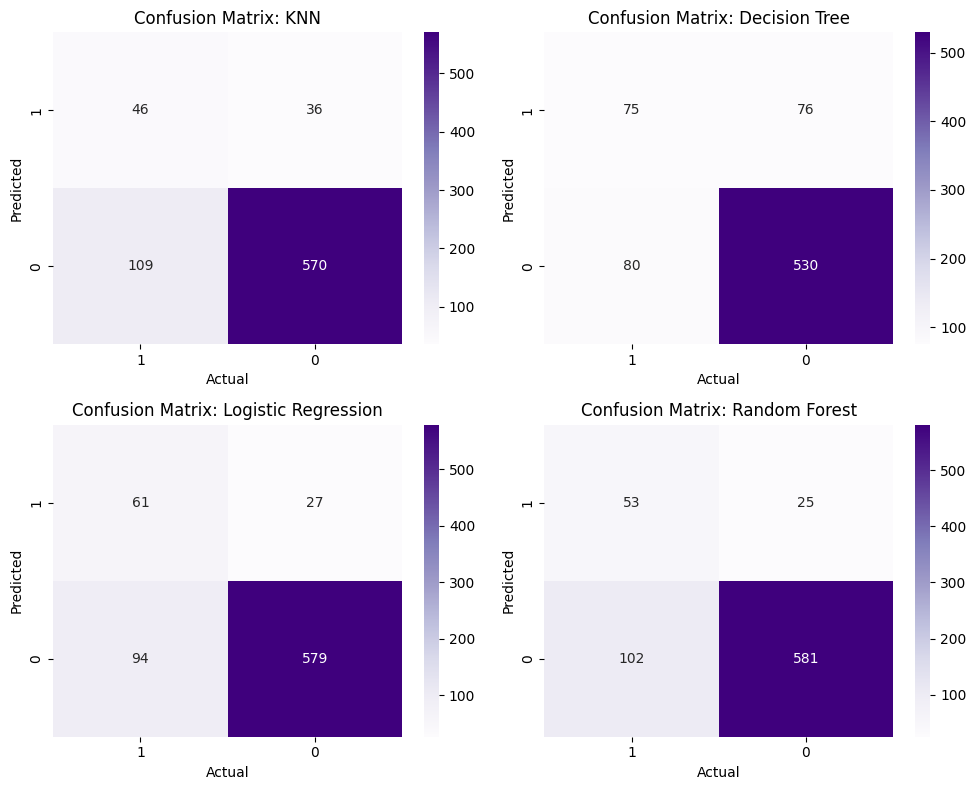

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    # Это поставит класс 1 на первое место
    cm = confusion_matrix(y_test, res['y_pred'], labels=[1, 0])
    cm_transposed = cm.T  # или np.transpose(cm)
    sns.heatmap(cm_transposed, annot=True, fmt='d', cmap='Purples', ax=axes[idx])

    # Явно задаём подписи: 1 сверху/слева, 0 снизу/справа
    axes[idx].set_xticklabels(['1', '0'])  # Actual: 1, затем 0
    axes[idx].set_yticklabels(['1', '0'])  # Predicted: 1, затем 0
    
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

**Выводы:**

Матрицы ошибок наглядно иллюстрируют распределение предсказаний моделей по четырём категориям:
TP (True Positive, верхний левый угол) — правильно выявленные дефолтные клиенты (класс 1);
FP (False Positive, верхний правый) — ложные срабатывания (надёжных клиентов ошибочно отнесли к дефолтным);
FN (False Negative, нижний левый) — пропущенные дефолты (рискованных клиентов посчитали надёжными);
TN (True Negative, нижний правый) — правильно определённые надёжные клиенты (класс 0).

Общие наблюдения:
Во всех моделях доминирует TN (около 570–581), что подтверждает сильный дисбаланс классов и высокую общую точность за счёт правильного предсказания мажоритарного класса 0.
FN значительно превышает TP у всех моделей — это наиболее критичная ошибка в задаче кредитного скоринга, поскольку пропуск дефолтного клиента может привести к реальным финансовым убыткам банка.

Сравнение моделей:

-	KNN: TP = 46, FP = 36, FN = 109, TN = 570. Модель относительно агрессивная — имеет наименьшее количество FN (109), но при этом больше ложных срабатываний (FP = 36). Подходит, если приоритет — максимально выявить риски.

-	Decision Tree: TP = 75, FP = 76, FN = 80, TN = 530. Самый несбалансированный результат: много как FP, так и FN. Подтверждает переобучение и нестабильность одиночного дерева.

-	Logistic Regression: TP = 61, FP = 27, FN = 94, TN = 579. Самая консервативная модель — минимальное количество FP (27), то есть редко ошибается, когда отказывает в кредите. Однако пропускает много реальных дефолтов (FN = 94).

-	Random Forest: TP = 53, FP = 25, FN = 102, TN = 581. Наилучший баланс ошибок: минимальные FP (25) среди нелинейных моделей и приемлемое количество TP. Модель осторожна, но надёжна — лучше всего минимизирует ложные отказы добросовестным клиентам при сохранении приемлемого уровня выявления рисков.



## 7. Построение ROC-кривых для всех моделей

**roc_curve(y_test, res['y_proba'])** - Функция вычисляет координаты точек для построения ROC-кривой:

Параметры:

y_test — реальные классы (0 или 1)

res['y_proba'] — вероятности класса 1 от модели

Возвращает 3 массива:

fpr (False Positive Rate) — координаты X

tpr (True Positive Rate) — координаты Y

_ — пороги (нам не нужны, поэтому _)

**auc(fpr, tpr)** - Вычисляет площадь под кривой (AUC):


**plt.plot(fpr, tpr, ...)** - Рисует одну ROC-кривую на графике для конкретной модели

lw=2 - linewidth = толщина линии (2 пикселя).

label=f'{name} (AUC = {roc_auc:.3f})' - Подпись линии в легенде

**plt.plot([0, 1], [0, 1], color='gray', linestyle='--')** - Диагональ случайного угадывания

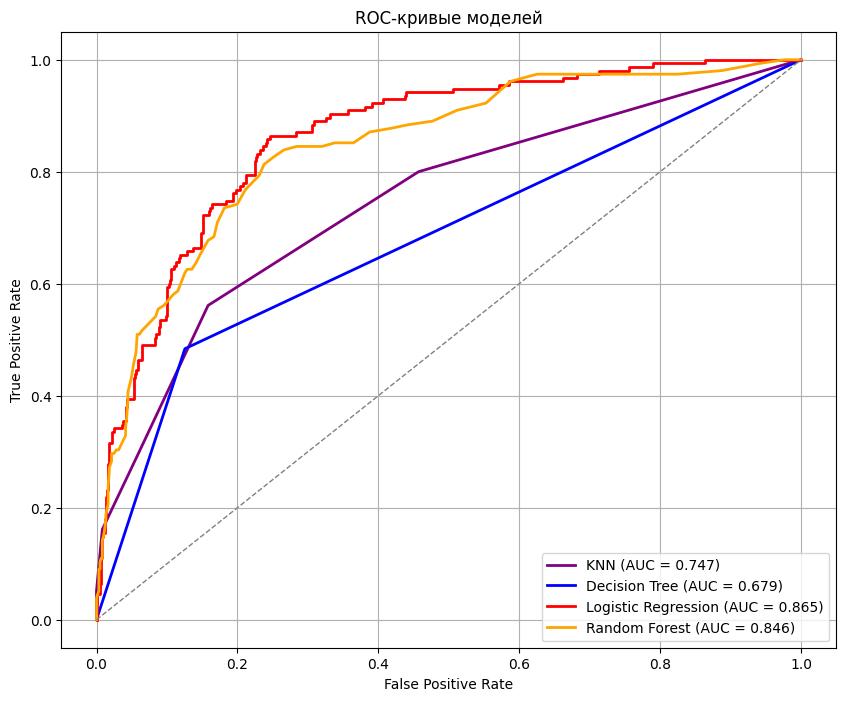

In [10]:
colors = ['purple', 'blue', 'red', 'orange']

plt.figure(figsize=(10, 8))
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        lw=2,
        color=color,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


**Выводы:**

Анализ ROC-кривых полностью согласуется с ранее полученными метриками качества и матрицами ошибок. ROC-кривая отражает зависимость доли правильно выявленных дефолтных заёмщиков (True Positive Rate) от доли ошибочно отнесённых к дефолту надёжных клиентов (False Positive Rate) при изменении порога классификации. Площадь под кривой (AUC) служит обобщённой мерой способности модели разделять классы независимо от выбранного порога.
Результаты по моделям:

-	Logistic Regression показала наилучший результат (AUC = 0.865) — её кривая (красная) расположена ближе всего к левому верхнему углу, что свидетельствует о превосходном балансе между чувствительностью и специфичностью на всём диапазоне порогов. Это делает модель идеальной для задач, где требуется надёжное ранжирование заёмщиков по уровню риска.

-	Random Forest уверенно занимает второе место (AUC = 0.846, оранжевая кривая) — разница с лидером минимальна, а кривая практически примыкает к логистической регрессии на большей части графика.

-	KNN демонстрирует заметно более слабую разделяющую способность (AUC = 0.747, фиолетовая кривая) — кривая проходит значительно ниже лидеров, особенно в зоне низких FPR.
-	Decision Tree ожидаемо оказался худшим (AUC = 0.679, синяя кривая) — его траектория ближе всего к диагональной линии случайного классификатора, что подтверждает низкую обобщающую способность и склонность к переобучению.


## Выводы по проделанной работе

В рамках лабораторной работы был выполнен полный цикл решения задачи бинарной классификации на реальном датасете кредитного скоринга. Набор данных включал разнообразные признаки заёмщиков (возраст, доход, тип занятости, образование, кредитный рейтинг, наличие просрочек и др.), а целевой переменной служил факт дефолта по кредиту (Default = 1 — дефолт, Default = 0 — выплата без нарушений).

Предобработка данных включала проверку типов и пропусков, преобразование категориальных признаков в тип category с последующим One-Hot кодированием, а также стандартизацию числовых атрибутов. Визуальный анализ (pairplot и матрицы сопряженности) выявил выраженный дисбаланс классов — доля дефолтных клиентов составляла лишь около 15–20 %, а также подтвердил высокую информативность признаков credit_score и interest_rate_pct для разделения классов.
Были реализованы и сравнены четыре алгоритма классификации: KNeighborsClassifier, DecisionTreeClassifier, LogisticRegression и 
RandomForestClassifier. Лучшие показатели продемонстрировали:

- Random Forest — лидер по общей точности (Accuracy ≈ 0.833–0.850), Precision, F1-score и сбалансированным метрикам, благодаря ансамблированию и устойчивости к переобучению.
- Logistic Regression — наивысший ROC-AUC (≈ 0.865), что говорит о превосходной способности модели ранжировать заёмщиков по вероятности дефолта.

Одиночное дерево решений показало наихудшие результаты из-за высокой дисперсии и переобучения, а KNN занял промежуточное положение. Матрицы ошибок и анализ метрик подтвердили общую проблему всех моделей — низкий Recall для класса дефолта (1): модели склонны к консервативной стратегии, предпочитая пропускать рискованных клиентов (FN), чтобы минимизировать ложные отказы надёжным заёмщикам (FP).


# Доп.задания

## Задание 10

Задача: Осуществить подбор оптимальных параметров с помощью GridSearchCV для случайного леса. Сравнить качество модели для подобранных параметров и
любых других.

1) Модель случайного леса

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

rf_base = RandomForestClassifier(random_state=0)
rf_base.fit(X_train_processed, y_train)

y_pred_base = rf_base.predict(X_test_processed)
y_proba_base = rf_base.predict_proba(X_test_processed)[:, 1]

base_metrics = {
    'Accuracy': metrics.accuracy_score(y_test, y_pred_base),
    'Precision': metrics.precision_score(y_test, y_pred_base),
    'Recall': metrics.recall_score(y_test, y_pred_base),
    'F1': metrics.f1_score(y_test, y_pred_base),
    'Balanced Accuracy': metrics.balanced_accuracy_score(y_test, y_pred_base),
    'ROC AUC': metrics.roc_auc_score(y_test, y_proba_base)
}

base_metrics

{'Accuracy': 0.8331143232588699,
 'Precision': 0.6794871794871795,
 'Recall': 0.3419354838709677,
 'F1': 0.45493562231759654,
 'Balanced Accuracy': np.float64(0.6503406792292132),
 'ROC AUC': np.float64(0.8455711700202279)}

2) Подбор гиперпараметров

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=0)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

3. Вычисление метрик после GridSearchCV

In [14]:
rf_best = grid_search.best_estimator_

y_pred_best = rf_best.predict(X_test_processed)
y_proba_best = rf_best.predict_proba(X_test_processed)[:, 1]

best_metrics = {
    'Accuracy': metrics.accuracy_score(y_test, y_pred_best),
    'Precision': metrics.precision_score(y_test, y_pred_best),
    'Recall': metrics.recall_score(y_test, y_pred_best),
    'F1': metrics.f1_score(y_test, y_pred_best),
    'Balanced Accuracy': metrics.balanced_accuracy_score(y_test, y_pred_best),
    'ROC AUC': metrics.roc_auc_score(y_test, y_proba_best)
}

best_metrics

{'Accuracy': 0.8383705650459922,
 'Precision': 0.7162162162162162,
 'Recall': 0.3419354838709677,
 'F1': 0.462882096069869,
 'Balanced Accuracy': np.float64(0.6536410092622165),
 'ROC AUC': np.float64(0.8525870328968379)}

4. Сравнение модели до и после подсчета гиперпараметров

In [15]:
comparison_df = pd.DataFrame({
    'Random Forest (default)': base_metrics,
    'Random Forest (GridSearch)': best_metrics
})

comparison_df

,Random Forest (default),Random Forest (GridSearch)
Accuracy,0.833114,0.838371
Precision,0.679487,0.716216
Recall,0.341935,0.341935
F1,0.454936,0.462882
Balanced Accuracy,0.650341,0.653641
ROC AUC,0.845571,0.852587


**Вывод по проделанному заданию:**

В рамках дополнительного исследования был выполнен подбор оптимальных гиперпараметров модели Random Forest с использованием метода GridSearchCV. Качество базовой модели и модели с подобранными параметрами сравнивалось на тестовой выборке с использованием метрик Accuracy, Precision, Recall, F1-score, Balanced Accuracy и ROC AUC.

Анализ полученных результатов показал, что модель случайного леса с подобранными гиперпараметрами демонстрирует улучшение большинства показателей качества по сравнению с базовой конфигурацией. В частности, наблюдается рост точности классификации (Accuracy), а также заметное увеличение метрики Precision, что свидетельствует о снижении количества ложноположительных срабатываний при прогнозировании дефолта.

Значение Recall в обеих моделях осталось неизменным, что указывает на то, что способность модели выявлять объекты положительного класса не изменилась. Тем не менее, за счёт повышения точности предсказаний положительного класса и более сбалансированного разделения объектов улучшились значения F1-score и Balanced Accuracy, что говорит о повышении общего качества модели в условиях несбалансированных классов.

Дополнительно отмечается рост значения ROC AUC, что указывает на более высокую способность модели с подобранными параметрами корректно ранжировать объекты по вероятности принадлежности к классу дефолта.

Таким образом, использование метода GridSearchCV позволило получить модель случайного леса с более высокими и устойчивыми показателями качества по сравнению с базовой версией. Полученные результаты подтверждают целесообразность подбора гиперпараметров для повышения эффективности классификации в задаче прогнозирования кредитного дефолта.

## Задание 14

Задача: Написать программу, которая для дерева решений для разного параметра max_depth будет считать accuracy_score для тренировочных и тестовых данных (использовать predict на X_train и X_valid). Выполнить визуализацию: по оси х - значение параметра max_depth (от 1 до 16), по оси y - Accuracy, построить две линии для тренировочных и тестовых данных.

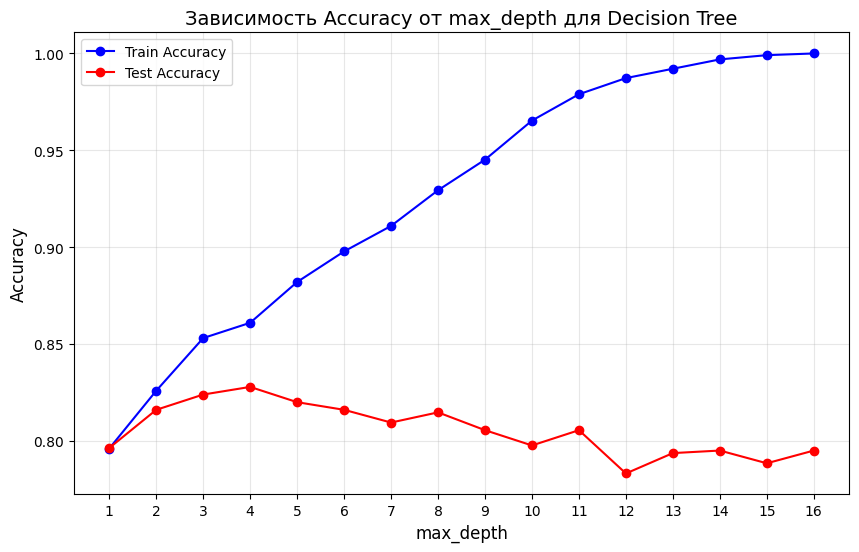

In [16]:
# Диапазон max_depth
depth_range = range(1, 17)

# Списки для хранения точности
train_acc = []
test_acc = []

# Проходим по всем значениям max_depth
for depth in depth_range:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=0)
    dt.fit(X_train_processed, y_train)
    
    # Предсказания
    y_train_pred = dt.predict(X_train_processed)
    y_test_pred = dt.predict(X_test_processed)
    
    # Считаем accuracy
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

# Визуализация
plt.figure(figsize=(10,6))
plt.plot(depth_range, train_acc, marker='o', label='Train Accuracy', color='blue')
plt.plot(depth_range, test_acc, marker='o', label='Test Accuracy', color='red')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Зависимость Accuracy от max_depth для Decision Tree', fontsize=14)
plt.xticks(depth_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Вывод к графику:**

График зависимости Accuracy от параметра max_depth для модели Decision Tree наглядно демонстрирует классический случай переобучения. 

Синяя линия (Train Accuracy) показывает, что точность на обучающей выборке монотонно возрастает с увеличением глубины дерева — начиная с примерно 0.80 при max_depth=1 и достигая почти 1.00 при max_depth≥10. Это указывает на то, что более глубокое дерево идеально подстраивается под тренировочные данные, захватывая даже шум и случайные особенности датасета.

В то же время красная линия (Test Accuracy) достигает пика (около 0.82–0.83) при небольшой глубине (max_depth=3–4), после чего начинает снижаться, опускаясь до уровня ~0.78 при max_depth=16. Такое поведение свидетельствует о потере обобщающей способности модели: глубокие деревья слишком сложны, они перестают эффективно обобщать на новые данные, что приводит к росту ошибок на тестовой выборке.
В контексте задачи кредитного скоринга это подчеркивает важность регуляризации: оптимальная глубина дерева (3–4) обеспечивает баланс между подгонкой под данные и избежанием переобучения, минимизируя риски ложных предсказаний дефолта. Для дальнейшего улучшения рекомендуется использовать техники обрезк или переход к ансамблевым методам, таким как Random Forest, которые, как показано в основной части работы, лучше справляются с этой проблемой.

## Задание 16

Задача: Проверить является ли датасет сбалансированным относительно распределения классов. Устранить дисбаланс классов и заново провести анализ, сделать выводы.

1. Проверка баланса классов

Распределение классов:
 Default
0    2421
1     620
Name: count, dtype: int64


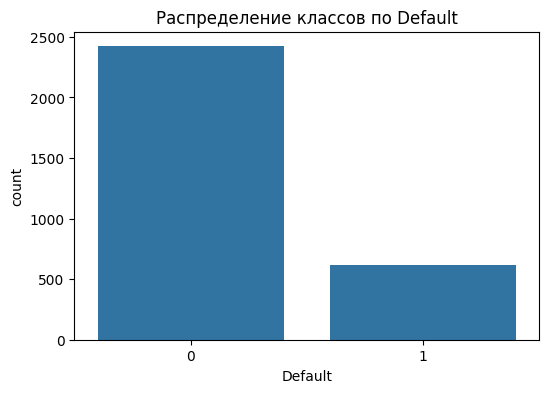

In [17]:
# Подсчёт объектов каждого класса
class_counts = y.value_counts()
print("Распределение классов:\n", class_counts)

# Визуализация распределения
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title('Распределение классов по Default')
plt.show()

Вывод: исходя из распредления видно, что наблюдается дисбаланс классов, нулей гораздо больше единиц

2. Устранение дисбаланса

Для исправления дисбаланса был использован метод Random Oversampling из библиотеки imblearn. 

Реализация метода:

- Создаются дополнительные копии объектов меньшего класса до тех пор, пока количество объектов классов не станет одинаковым.
- Это позволяет модели видеть равное количество примеров для каждого класса во время обучения.
- Метод не изменяет существующие объекты, а лишь увеличивает их число, обеспечивая балансировку без потери информации.

Преимущество Random Oversampling в том, что он прост в реализации и хорошо работает на небольших и средних наборах данных. После балансировки классы стали примерно равны по количеству объектов, что позволило повторно обучить все модели и корректно оценить их метрики на сбалансированном датасете.

In [22]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)
X_res, y_res = ros.fit_resample(X, y)

print("После балансировки:")
print(pd.Series(y_res).value_counts())

После балансировки:
Default
0    2421
1    2421
Name: count, dtype: int64


3. Разделение на тренировочную и тестовую выборки

In [23]:
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X_res, y_res, test_size=0.25, random_state=0, stratify=y_res
)

4. Предобработка признаков

In [24]:
# Числовые и категориальные колонки
numeric_cols_res = X_train_res.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_res = X_train_res.select_dtypes(include=['category','object']).columns.tolist()

# Стандартизация числовых
scaler_res = StandardScaler()
X_train_num_scaled_res = scaler_res.fit_transform(X_train_res[numeric_cols_res])
X_test_num_scaled_res = scaler_res.transform(X_test_res[numeric_cols_res])

# One-Hot кодирование категориальных
X_train_cat_res = pd.get_dummies(X_train_res[categorical_cols_res])
X_test_cat_res = pd.get_dummies(X_test_res[categorical_cols_res])

# Объединяем признаки
X_train_processed_res = pd.DataFrame(
    np.hstack([X_train_num_scaled_res, X_train_cat_res]),
    columns=numeric_cols_res + list(X_train_cat_res.columns)
)
X_test_processed_res = pd.DataFrame(
    np.hstack([X_test_num_scaled_res, X_test_cat_res]),
    columns=numeric_cols_res + list(X_test_cat_res.columns)
)

5. Обучение моделей и сбор метрик

In [25]:
# Инициализация моделей
models_res = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=0),
    'Random Forest': RandomForestClassifier(random_state=0)
}

# Обучение и предсказание
results_res = {}
for name, model in models_res.items():
    model.fit(X_train_processed_res, y_train_res)
    y_pred = model.predict(X_test_processed_res)
    y_proba = model.predict_proba(X_test_processed_res)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test_res)
    
    results_res[name] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }

# Вычисление метрик
metrics_df_res = pd.DataFrame()
for name, res in results_res.items():
    metrics_res = evaluate_model(y_test_res, res['y_pred'], res['y_proba'])
    metrics_df_res[name] = pd.Series(metrics_res)

print("Метрики моделей на сбалансированном датасете:")
print(metrics_df_res.T)


Метрики моделей на сбалансированном датасете:
                     Accuracy  Precision    Recall        F1  \
KNN                  0.796036   0.759420  0.866116  0.809266   
Decision Tree        0.900083   0.848703  0.973554  0.906851   
Logistic Regression  0.798514   0.791599  0.809917  0.800654   
Random Forest        0.940545   0.911901  0.975207  0.942492   

                     Balanced Accuracy   ROC AUC  
KNN                           0.796094  0.887317  
Decision Tree                 0.900143  0.900143  
Logistic Regression           0.798523  0.871964  
Random Forest                 0.940574  0.992656  


6. Построение ROC-кривых для всех моделей

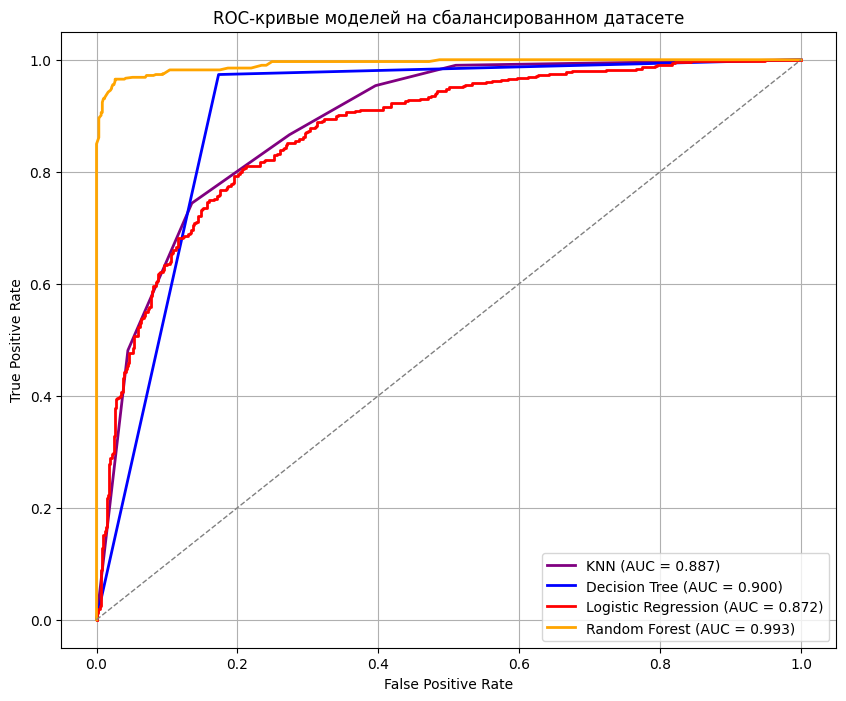

In [26]:
colors = ['purple', 'blue', 'red', 'orange']

plt.figure(figsize=(10,8))
for (name, res), color in zip(results_res.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_res, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей на сбалансированном датасете')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

7. Сравнение и выводы

**Сравнение метрик качества моделей до и после устранения дисбаланса классов:**

Применение Random Oversampling существенно улучшило способность моделей выявлять дефолтных клиентов. На несбалансированном датасете все модели демонстрировали высокую Accuracy (0.795–0.841), но за счёт преимущественного предсказания мажоритарного класса 0, что приводило к низкому Recall (0.297–0.484) и F1-score (0.388–0.502). После балансировки Recall вырос до 0.810–0.975, F1-score — до 0.801–0.942, Balanced Accuracy — до 0.796–0.941, а ROC AUC — до 0.887–0.993.

Наиболее впечатляющий рост показали ансамблевые методы: Random Forest достиг выдающихся результатов (Accuracy 0.941, F1 0.942, ROC AUC 0.993), Decision Tree также значительно улучшился (F1 0.907, ROC AUC 0.900). KNN и Logistic Regression показали умеренное улучшение, но уступили нелинейным моделям.

Устранение дисбаланса методом Random Oversampling сделало модели гораздо более чувствительными к миноритарному классу, что критично для кредитного скоринга — снижение количества пропущенных дефолтов (FN) потенциально уменьшает финансовые потери банка. Однако следует отметить, что oversampling может привести к переобучению на дублированных примерах. В целом, Random Forest подтверждает своё превосходство как наиболее эффективной модели для данной задачи.

**Выводы по ROC-кривам:**

На исходном несбалансированном датасете лучшие результаты по площади под ROC-кривой (AUC) демонстрируют Logistic Regression (0.865) и Random Forest (0.846) — их кривые расположены выше и ближе к левому верхнему углу, что свидетельствует о хорошей разделяющей способности даже при сильном дисбалансе. Decision Tree показывает наихудший результат (AUC = 0.679), а KNN — промежуточный (AUC = 0.747).
После применения Random Oversampling наблюдается значительный рост AUC для всех моделей, что подтверждает положительное влияние балансировки на качество ранжирования:

- Random Forest достигает выдающегося значения AUC = 0.993 — кривая практически прижата к левому верхнему углу, указывая на отличную способность модели разделять классы.
- Decision Tree улучшился до AUC = 0.900 (рост на ~0.22).
- KNN — до AUC = 0.887 (рост на ~0.14).
- Logistic Regression — до AUC = 0.872 (незначительный рост с 0.865).

Особенно заметен прогресс нелинейных моделей (Random Forest и Decision Tree), которые лучше используют дополнительную информацию из дублированных примеров миноритарного класса. Random Forest подтверждает своё лидерство: значение AUC 0.993 близко к идеальному и делает модель практически безупречной в задаче вероятностного ранжирования риска дефолта.

В целом, сравнение ROC-кривых до и после балансировки наглядно иллюстрирует, что устранение дисбаланса методом Random Oversampling не только повышает чувствительность моделей к дефолтным клиентам (как видно по метрикам Recall и F1), но и существенно улучшает их общую разделяющую способность. Это делает сбалансированные модели, особенно Random Forest, предпочтительными для практического применения в кредитном скоринге, где важна не только классификация, но и ранжирование заявок по уровню риска.

**Итого:** 

Устранение дисбаланса классов методом Random Oversampling существенно повысило качество классификации в задаче предсказания дефолта по кредитам. На несбалансированном датасете модели демонстрировали высокую общую точность, но низкую чувствительность к миноритарному классу (дефолт), что приводило к частым пропускам рискованных клиентов. После балансировки метрики (Recall, F1-score, Balanced Accuracy) выросли в 1.5–2 раза, а ROC AUC — до 0.887–0.993, с лидерством Random Forest (AUC 0.993). Это подтверждает критичность балансировки для задач с имбалансом, улучшая обобщающую способность моделей и минимизируя финансовые риски в кредитном скоринге. Рекомендуется комбинировать oversampling с кросс-валидацией для предотвращения переобучения на дубликатах.

## Задание 17

Задача: Применить StratifiedKFold , получить результаты и сделать выводы.

1. StratifiedKFold с 5 фолдами: Делит тренировочный набор на 5 частей, при этом пропорции классов в каждой части сохраняются.
4 части используются для обучения, 1 часть — для проверки. Процесс повторяется 5 раз.
2. cross_val_score: Для каждой модели вычисляет метрику accuracy на каждом фолде.
3. Для каждой модели показываются значения Accuracy по фолдам и средняя Accuracy.

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Используем StratifiedKFold с 5 фолдами
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Инициализация моделей (как в основной работе)
models_skf = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=0),
    'Random Forest': RandomForestClassifier(random_state=0)
}

# Словарь для хранения средних accuracy
cv_results = {}

for name, model in models_skf.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Accuracy по фолдам: {scores}')
    print(f'  Средняя Accuracy: {scores.mean():.4f}\n')


KNN:
  Accuracy по фолдам: [0.83991228 0.82675439 0.82236842 0.83333333 0.8377193 ]
  Средняя Accuracy: 0.8320

Decision Tree:
  Accuracy по фолдам: [0.79605263 0.77850877 0.8004386  0.78289474 0.80263158]
  Средняя Accuracy: 0.7921

Logistic Regression:
  Accuracy по фолдам: [0.86842105 0.83991228 0.85745614 0.84210526 0.87280702]
  Средняя Accuracy: 0.8561

Random Forest:
  Accuracy по фолдам: [0.87061404 0.85526316 0.86184211 0.85307018 0.86403509]
  Средняя Accuracy: 0.8610



**Вывод по кросс-валидации с использованием StratifiedKFold:**

Была проведена кросс-валидация моделей с использованием StratifiedKFold (5 фолдов), что позволило сохранить пропорции классов в каждом фолде и оценить стабильность моделей.

Результаты показали следующее:

- KNN: средняя точность 0.8320, небольшие колебания по фолдам (0.822–0.840), что свидетельствует о достаточно стабильной работе метода.
- Decision Tree: средняя точность 0.7921, заметна вариативность по фолдам (0.779–0.803), что указывает на более чувствительную зависимость от структуры данных.
- Logistic Regression: средняя точность 0.8561, стабильные значения по фолдам (0.840–0.873), метод демонстрирует высокую общую точность и надёжность.
- Random Forest: средняя точность 0.8610, колебания по фолдам минимальны (0.853–0.871), модель показывает наилучшее качество и устойчивость к различным подвыборкам.

Итого: StratifiedKFold подтвердил, что Random Forest и Logistic Regression являются наиболее точными и стабильными моделями для данного набора данных. Метод позволяет получить более надёжную оценку качества моделей по сравнению с обычным разовым разбиением на тренировочную и тестовую выборки.